# IPL Matches Data Cleaning & Visualization
**Internship Project — Thiranex | Data Science**

This notebook covers:
- Data loading and exploration
- Handling missing values, outliers, and duplicates
- Visualizing key insights using Matplotlib and Seaborn

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv('../data/matches.csv')

print('Shape:', df.shape)
print()
df.head()

Shape: (1095, 20)



,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


## 3. Data Exploration

In [3]:
print('=== Column Info ===')
df.info()
print()
print('=== Basic Statistics ===')
df.describe()

=== Column Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


## 4. Data Cleaning
### 4a. Check & Handle Missing Values

Missing values per column:
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


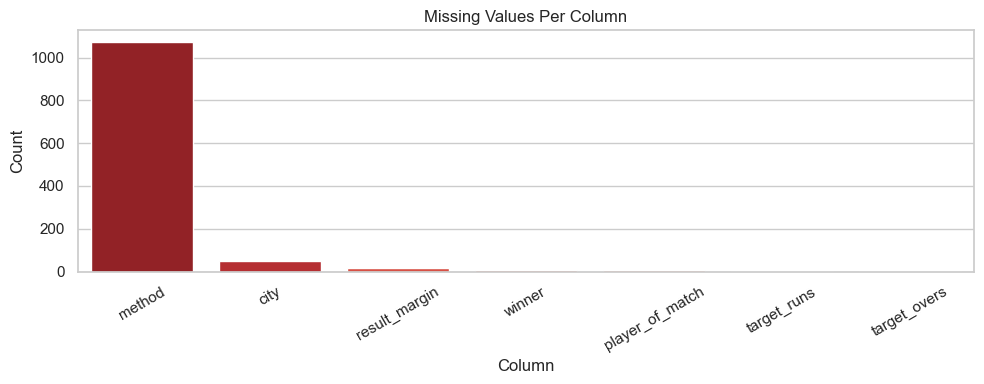

Saved: missing_values.png


In [4]:
print('Missing values per column:')
print(df.isnull().sum())

# Visualize missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(x=missing.index, y=missing.values, palette='Reds_r')
plt.title('Missing Values Per Column')
plt.ylabel('Count')
plt.xlabel('Column')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../output/missing_values.png', dpi=150)
plt.show()
print('Saved: missing_values.png')

In [5]:
# Handle missing values

# 'method' column is 98% missing (only used for DLS method matches) — drop it
df.drop(columns=['method'], inplace=True)

# 'city' — fill missing with venue name (venue contains city info)
df['city'] = df['city'].fillna(df['venue'].str.split(',').str[0])

# 'winner' & 'player_of_match' — 5 rows with no result (tie/no result)
df['winner'] = df['winner'].fillna('No Result')
df['player_of_match'] = df['player_of_match'].fillna('N/A')

# 'result_margin' — fill 0 for no result matches
df['result_margin'] = df['result_margin'].fillna(0)

# 'target_runs' & 'target_overs' — fill 0 where missing
df['target_runs'] = df['target_runs'].fillna(0)
df['target_overs'] = df['target_overs'].fillna(0)

print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
umpire1            0
umpire2            0
dtype: int64


### 4b. Check & Remove Duplicates

In [6]:
print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('Shape after removing duplicates:', df.shape)

Duplicate rows: 0
Shape after removing duplicates: (1095, 19)


### 4c. Fix Season Column & Data Types

In [7]:
# Normalize season: '2007/08' -> '2008', '2009/10' -> '2010', etc.
def normalize_season(s):
    if '/' in str(s):
        return int(str(s).split('/')[0]) + 1
    return int(s)

df['season'] = df['season'].apply(normalize_season)

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

print('Seasons in dataset:', sorted(df['season'].unique()))
print('Date range:', df['date'].min(), 'to', df['date'].max())

Seasons in dataset: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Date range: 2008-04-18 00:00:00 to 2024-05-26 00:00:00


### 4d. Check Outliers in result_margin

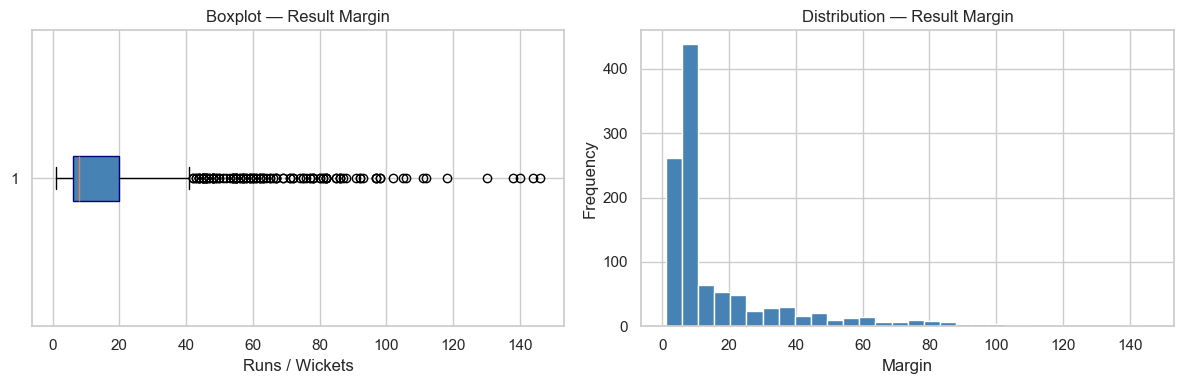

Outliers found via IQR: 121 (these are legitimate extreme wins, kept as-is)


In [8]:
# Only look at actual results (not No Result matches)
margins = df[df['result_margin'] > 0]['result_margin']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot
axes[0].boxplot(margins, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[0].set_title('Boxplot — Result Margin')
axes[0].set_xlabel('Runs / Wickets')

# Histogram
axes[1].hist(margins, bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution — Result Margin')
axes[1].set_xlabel('Margin')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../output/outliers_margin.png', dpi=150)
plt.show()

# IQR method
Q1 = margins.quantile(0.25)
Q3 = margins.quantile(0.75)
IQR = Q3 - Q1
outliers = margins[(margins < Q1 - 1.5*IQR) | (margins > Q3 + 1.5*IQR)]
print(f'Outliers found via IQR: {len(outliers)} (these are legitimate extreme wins, kept as-is)')

## 5. Data Visualization & Insights
### Chart 1 — Most Successful Teams (Total Wins)

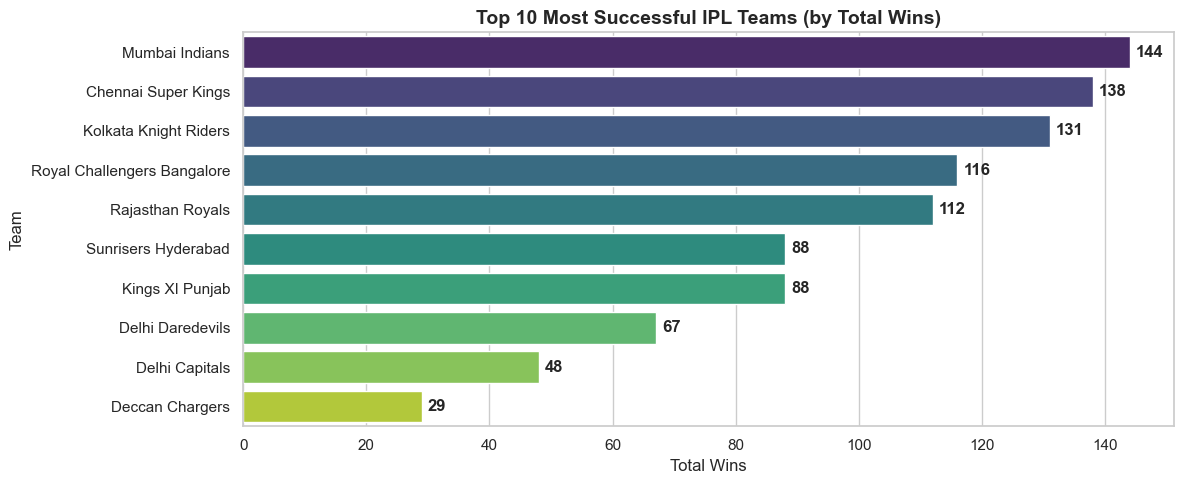


Insight: Mumbai Indians lead with the most wins in IPL history, followed by Chennai Super Kings — both consistently dominant franchises.


In [9]:
wins = df[df['winner'] != 'No Result']['winner'].value_counts().head(10)

plt.figure(figsize=(12, 5))
bars = sns.barplot(x=wins.values, y=wins.index, palette='viridis')
plt.title('Top 10 Most Successful IPL Teams (by Total Wins)', fontsize=14, fontweight='bold')
plt.xlabel('Total Wins')
plt.ylabel('Team')
for i, v in enumerate(wins.values):
    plt.text(v + 1, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../output/chart1_team_wins.png', dpi=150)
plt.show()

print('\nInsight: Mumbai Indians lead with the most wins in IPL history,'
      ' followed by Chennai Super Kings — both consistently dominant franchises.')

### Chart 2 — Toss Decision: Bat vs Field

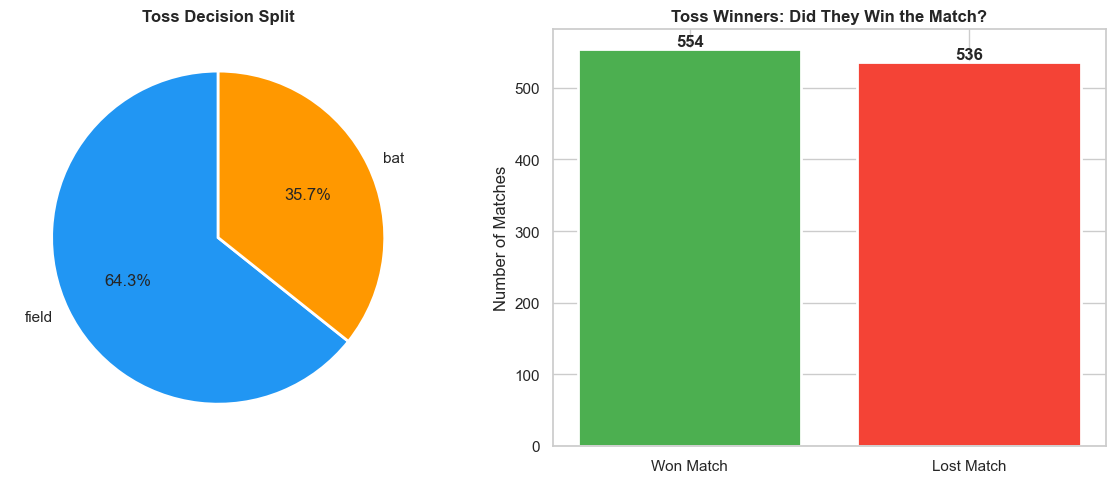


Insight: Teams winning the toss won the match only 50.8% of the time. Winning the toss gives only a slight edge — the game is still won on the field.


In [10]:
toss = df['toss_decision'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(toss.values, labels=toss.index, autopct='%1.1f%%',
            colors=['#2196F3', '#FF9800'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Toss Decision Split', fontweight='bold')

# Does toss win = match win?
df['toss_match_win'] = df['toss_winner'] == df['winner']
toss_win_rate = df[df['winner'] != 'No Result']['toss_match_win'].value_counts()

axes[1].bar(['Won Match', 'Lost Match'], toss_win_rate.values,
            color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=2)
axes[1].set_title('Toss Winners: Did They Win the Match?', fontweight='bold')
axes[1].set_ylabel('Number of Matches')
for i, v in enumerate(toss_win_rate.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../output/chart2_toss_analysis.png', dpi=150)
plt.show()

toss_win_pct = round(toss_win_rate.iloc[0] / toss_win_rate.sum() * 100, 1)
print(f'\nInsight: Teams winning the toss won the match only {toss_win_pct}% of the time.'
      ' Winning the toss gives only a slight edge — the game is still won on the field.')

### Chart 3 — Matches Per Season (IPL Growth)

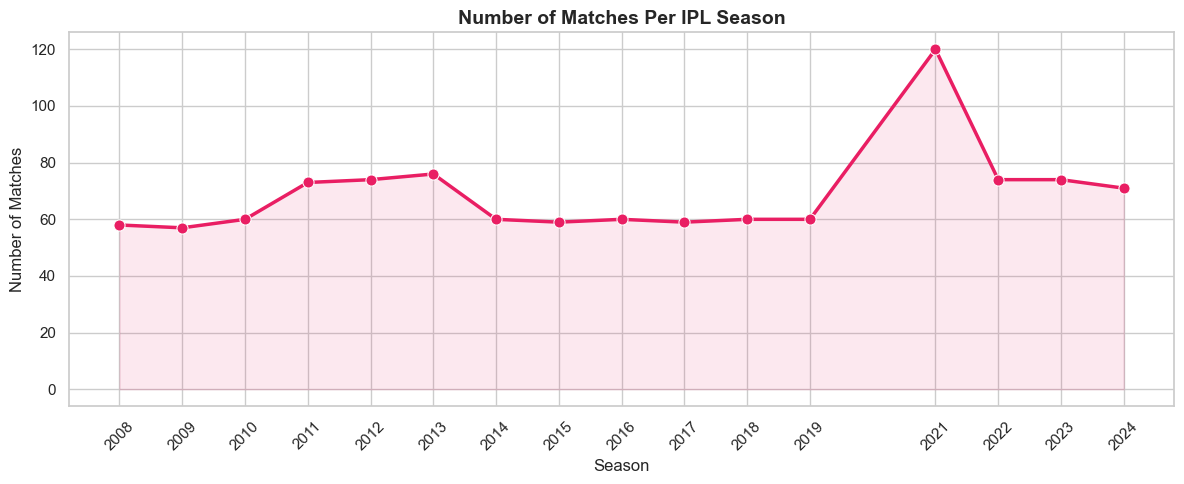


Insight: IPL started with 58 matches in 2008 and grew to 74 matches by 2023, reflecting the addition of new franchises and expanded league formats over the years.


In [11]:
matches_per_season = df.groupby('season').size().reset_index(name='matches')

plt.figure(figsize=(12, 5))
sns.lineplot(data=matches_per_season, x='season', y='matches',
             marker='o', color='#E91E63', linewidth=2.5, markersize=8)
plt.fill_between(matches_per_season['season'], matches_per_season['matches'],
                 alpha=0.1, color='#E91E63')
plt.title('Number of Matches Per IPL Season', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(matches_per_season['season'], rotation=45)
plt.tight_layout()
plt.savefig('../output/chart3_matches_per_season.png', dpi=150)
plt.show()

print('\nInsight: IPL started with 58 matches in 2008 and grew to 74 matches by 2023,'
      ' reflecting the addition of new franchises and expanded league formats over the years.')

### Chart 4 — Player of the Match Leaderboard

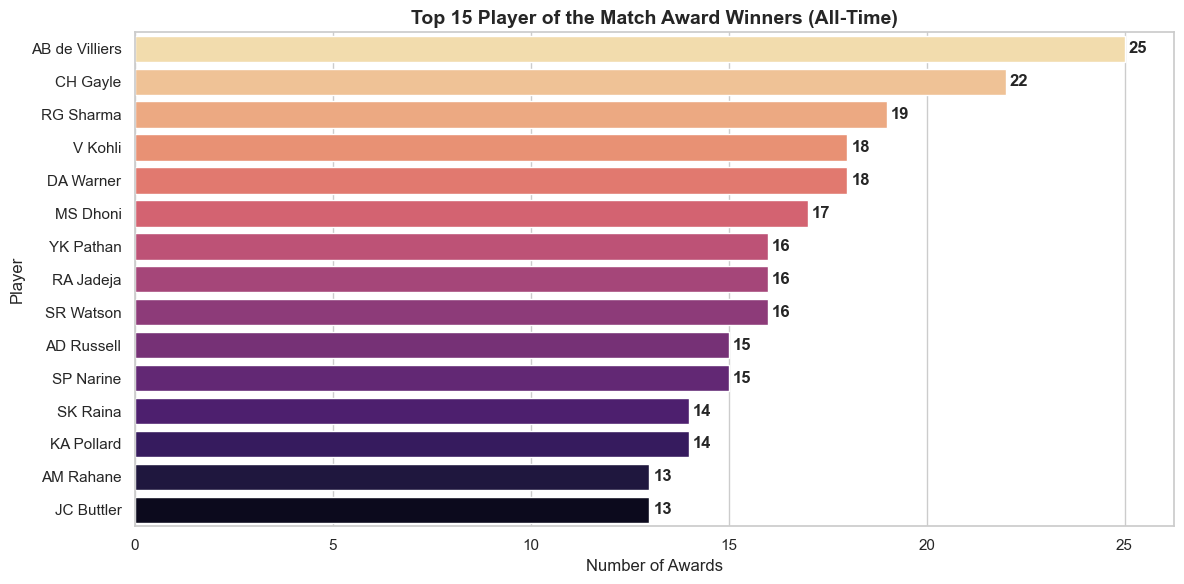


Insight: AB de Villiers leads all players in Player of the Match awards, highlighting consistent match-winning performances across multiple seasons.


In [12]:
potm = df[df['player_of_match'] != 'N/A']['player_of_match'].value_counts().head(15)

plt.figure(figsize=(12, 6))
bars = sns.barplot(x=potm.values, y=potm.index, palette='magma_r')
plt.title('Top 15 Player of the Match Award Winners (All-Time)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Awards')
plt.ylabel('Player')
for i, v in enumerate(potm.values):
    plt.text(v + 0.1, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../output/chart4_player_of_match.png', dpi=150)
plt.show()

print(f'\nInsight: {potm.index[0]} leads all players in Player of the Match awards,'
      ' highlighting consistent match-winning performances across multiple seasons.')

### Chart 5 — Win Type: Runs vs Wickets

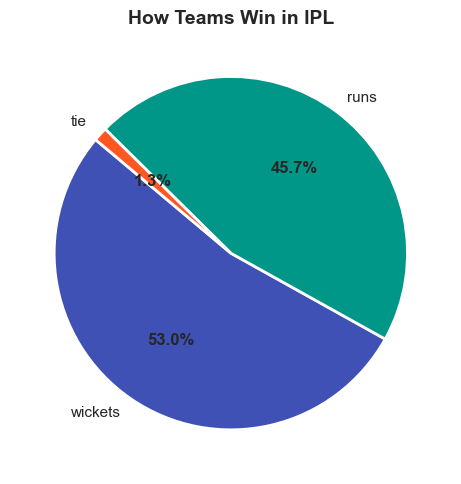


Insight: 53.0% of IPL matches are won by wickets (batting second), vs 45.7% by runs (batting first). Teams prefer chasing in T20 cricket.


In [13]:
win_type = df[df['winner'] != 'No Result']['result'].value_counts()

plt.figure(figsize=(8, 5))
wedges, texts, autotexts = plt.pie(
    win_type.values, labels=win_type.index,
    autopct='%1.1f%%', colors=['#3F51B5', '#009688', '#FF5722'],
    startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in autotexts:
    text.set_fontweight('bold')
plt.title('How Teams Win in IPL', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/chart5_win_type.png', dpi=150)
plt.show()

runs_pct = round(win_type.get('runs', 0) / win_type.sum() * 100, 1)
wickets_pct = round(win_type.get('wickets', 0) / win_type.sum() * 100, 1)
print(f'\nInsight: {wickets_pct}% of IPL matches are won by wickets (batting second),'
      f' vs {runs_pct}% by runs (batting first). Teams prefer chasing in T20 cricket.')

### Chart 6 — Top Venues by Matches Hosted

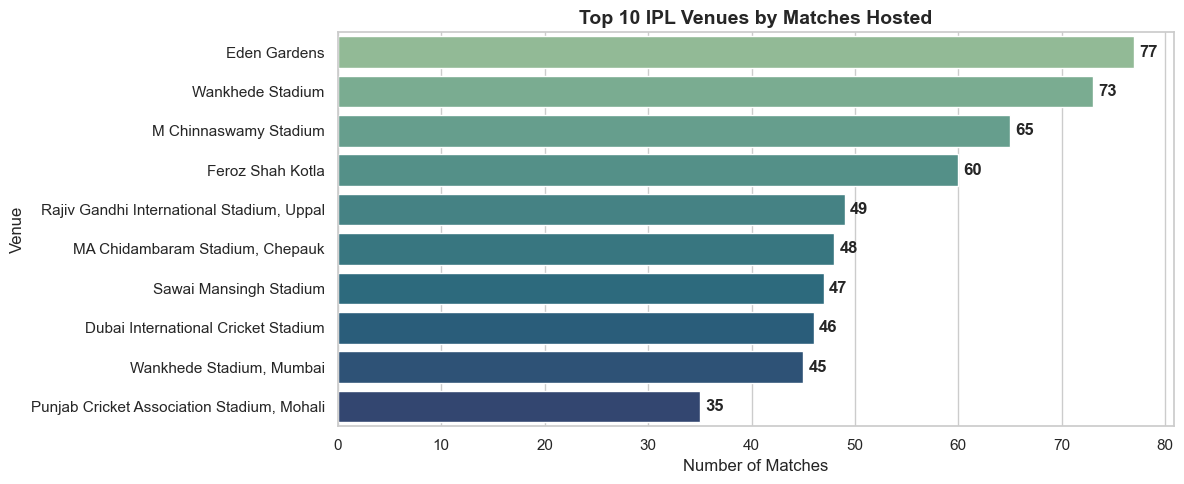


Insight: Eden Gardens has hosted the most IPL matches, making it the most iconic venue in IPL history.


In [14]:
venues = df['venue'].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=venues.values, y=venues.index, palette='crest')
plt.title('Top 10 IPL Venues by Matches Hosted', fontsize=14, fontweight='bold')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
for i, v in enumerate(venues.values):
    plt.text(v + 0.5, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../output/chart6_top_venues.png', dpi=150)
plt.show()

print(f'\nInsight: {venues.index[0]} has hosted the most IPL matches,'
      ' making it the most iconic venue in IPL history.')

## 6. Final Cleaned Dataset

In [15]:
df.to_csv('../data/matches_cleaned.csv', index=False)
print('Cleaned dataset saved to data/matches_cleaned.csv')
print('Final shape:', df.shape)
print('\nAll charts saved in the output/ folder.')
df.head()

Cleaned dataset saved to data/matches_cleaned.csv
Final shape: (1095, 20)

All charts saved in the output/ folder.


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,umpire1,umpire2,toss_match_win
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen,False
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,MR Benson,SL Shastri,True
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,Aleem Dar,GA Pratapkumar,False
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,SJ Davis,DJ Harper,False
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,BF Bowden,K Hariharan,False


## Summary

| Step | Action |
|---|---|
| Missing values | Dropped `method` column (98% missing), filled rest with logical defaults |
| Duplicates | No duplicates found |
| Outliers | Identified via IQR — extreme wins are valid data, kept as-is |
| Season fix | Normalized mixed formats like '2007/08' to single year |
| Visualizations | 6 charts covering wins, toss, venues, players, seasons |

**Key Findings:**
- Mumbai Indians are the most successful IPL franchise
- Winning the toss does NOT guarantee winning the match
- Most teams prefer to chase (bat second) in T20
- Wankhede / Eden Gardens / Chinnaswamy are the most iconic IPL venues